In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
import requests
import base64

# API Credentials
CLIENT_ID = "a3e9047d-7811-458e-9850-741dc082e379"
CLIENT_SECRET = "62122f8d-ccf1-4e33-85ad-e60e78743f0b"
TOKEN_URL = "https://digital.iservices.rte-france.com/token/oauth/"

# Encode Client Credentials
auth_string = f"{CLIENT_ID}:{CLIENT_SECRET}"
auth_encoded = base64.b64encode(auth_string.encode()).decode()

# Request Access Token
headers = {
    "Authorization": f"Basic {auth_encoded}",
    "Content-Type": "application/x-www-form-urlencoded"
}

data = {"grant_type": "client_credentials"}
response = requests.post(TOKEN_URL, data=data, headers=headers)

if response.status_code == 200:
    access_token = response.json().get("access_token")
    print("✅ Access Token:", access_token)
else:
    print("❌ Error:", response.text)


✅ Access Token: K2oZc3OxYAA8wg6yNDJ8BCMXU2U9HBQ4wSS3pyeVJA3l3cuNSPMoC2


In [4]:
import requests
import os

# Securely store your credentials in environment variables (Recommended)
CLIENT_ID = os.getenv("RTE_CLIENT_ID", "a3e9047d-7811-458e-9850-741dc082e379")
CLIENT_SECRET = os.getenv("RTE_CLIENT_SECRET", "62122f8d-ccf1-4e33-85ad-e60e78743f0b")

TOKEN_URL = "https://digital.iservices.rte-france.com/token/oauth/"
API_URL = "https://digital.iservices.rte-france.com/open_api/generation_forecast/v2/forecasts"

# Step 1: Get Access Token
def get_access_token():
    response = requests.post(
        TOKEN_URL,
        data={"grant_type": "client_credentials"},
        auth=(CLIENT_ID, CLIENT_SECRET)
    )

    if response.status_code == 200:
        access_token = response.json().get("access_token")
        print("✅ Access Token Received!")
        return access_token
    else:
        print(f"❌ Token Error: {response.status_code} - {response.text}")
        return None

# Step 2: Request Data from API
def fetch_forecast_data(access_token):
    headers = {"Authorization": f"Bearer {access_token}", "Content-Type": "application/json"}
    params = {
        "production_type": "SOLAR",  # Example: Fetching solar power forecast
        "type": "D-1",  # Day-ahead forecast
        "start_date": "2024-02-15T00:00:00+01:00",
        "end_date": "2024-02-16T00:00:00+01:00"
    }

    response = requests.get(API_URL, headers=headers, params=params)

    if response.status_code == 200:
        print("✅ Data Retrieved Successfully!")
        return response.json()
    elif response.status_code == 403:
        print("❌ Forbidden: Check API subscription or permissions.")
    elif response.status_code == 401:
        print("❌ Unauthorized: Invalid token.")
    else:
        print(f"❌ API Error: {response.status_code} - {response.text}")

# Execute API Calls
token = get_access_token()
if token:
    data = fetch_forecast_data(token)
    print("🔹 Forecast Data:", data)


✅ Access Token Received!
❌ Forbidden: Check API subscription or permissions.
🔹 Forecast Data: None


In [5]:
# Read the CSV file
df = pd.read_csv('rte_historical_energy.csv', parse_dates=['Timestamp'])


In [12]:
# Basic statistical analysis
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Timestamp,Solaire (MW),Éolien (MW),Hydroélectrique (MW),Gaz (MW),Cycle à Vapeur (MW),Hour
count,800,800.000000,800.000000,800.000000,800.000000,800.000000,800.0000
mean,2025-02-01 04:20:46.852378880,275.625000,213.368750,355.146250,603.440000,429.303750,11.5400
min,2025-01-15 12:50:46.852379,50.000000,30.000000,100.000000,200.000000,150.000000,0.0000
25%,2025-01-23 20:35:46.852378880,171.000000,122.750000,229.750000,410.000000,291.000000,6.0000
50%,2025-02-01 04:20:46.852378880,272.500000,211.000000,362.000000,605.500000,427.500000,12.0000
75%,2025-02-09 12:05:46.852378880,389.000000,314.000000,481.000000,806.250000,570.000000,17.2500
max,2025-02-17 19:50:46.852379,499.000000,399.000000,599.000000,999.000000,699.000000,23.0000
std,NaN,127.070081,108.077107,147.434328,229.452532,159.228967,6.9071


In [13]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

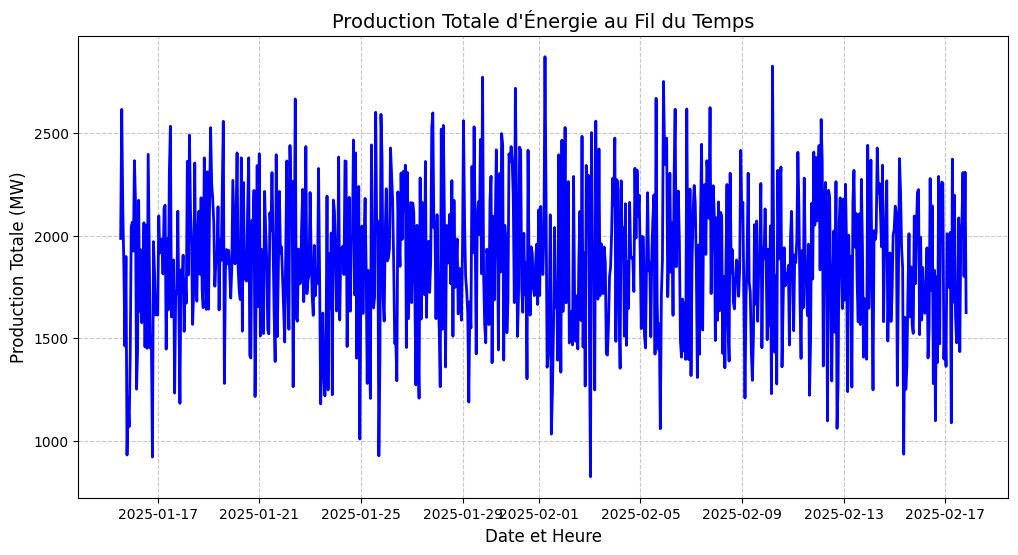

In [14]:
# Calculate total production (sum of all energy sources)
df['Total_Production'] = df['Solaire (MW)'] + df['Éolien (MW)'] + \
                        df['Hydroélectrique (MW)'] + df['Gaz (MW)'] + \
                        df['Cycle à Vapeur (MW)']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['Timestamp'], df['Total_Production'], 'b-', linewidth=2)

# Customize the plot
plt.title('Production Totale d\'Énergie au Fil du Temps', fontsize=14)
plt.xlabel('Date et Heure', fontsize=12)
plt.ylabel('Production Totale (MW)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

C:\Users\hey\AppData\Local\Temp\ipykernel_22912\1434341957.py:27: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


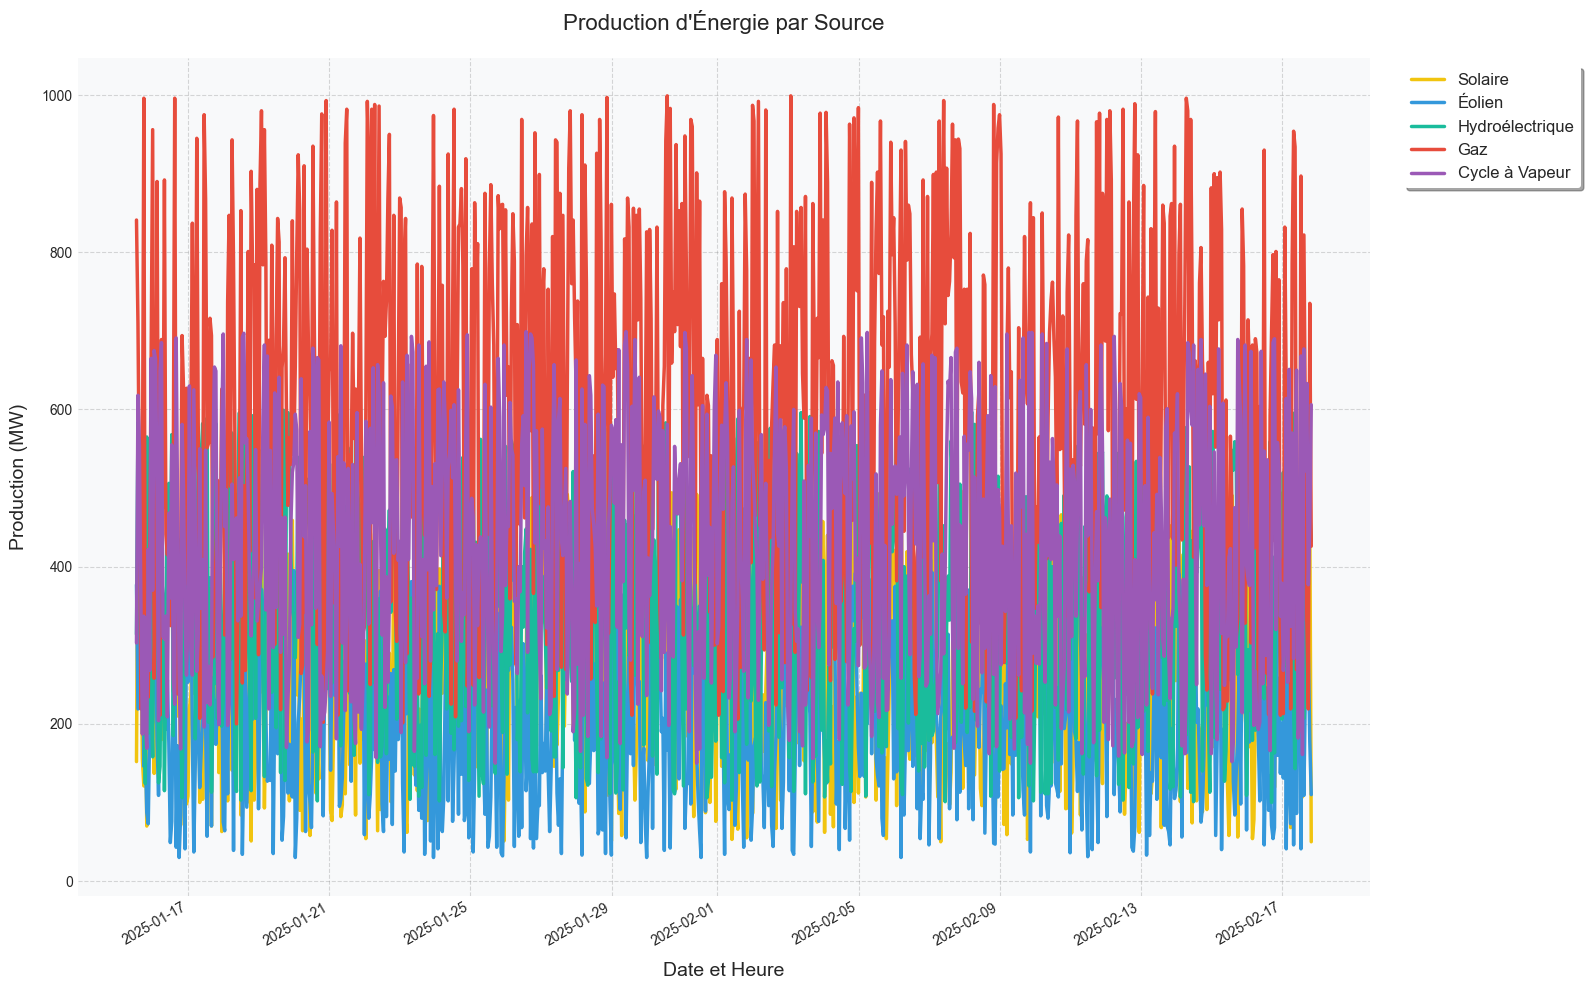


Statistiques de Production d'Énergie:
--------------------------------------------------

Solaire:
  Moyenne: 275.62 MW
  Maximum: 499.00 MW
  Minimum: 50.00 MW

Éolien:
  Moyenne: 213.37 MW
  Maximum: 399.00 MW
  Minimum: 30.00 MW

Hydroélectrique:
  Moyenne: 355.15 MW
  Maximum: 599.00 MW
  Minimum: 100.00 MW

Gaz:
  Moyenne: 603.44 MW
  Maximum: 999.00 MW
  Minimum: 200.00 MW

Cycle à Vapeur:
  Moyenne: 429.30 MW
  Maximum: 699.00 MW
  Minimum: 150.00 MW

Production Totale:
  Moyenne: 1,876.88 MW
  Maximum: 2,873.00 MW
  Minimum: 825.00 MW


In [18]:


# Calculate total production
df['Total_Production'] = df['Solaire (MW)'] + df['Éolien (MW)'] + \
                        df['Hydroélectrique (MW)'] + df['Gaz (MW)'] + \
                        df['Cycle à Vapeur (MW)']

# Create figure with larger size
plt.figure(figsize=(16, 10))

# Plot with improved styling

# Individual sources with vibrant colors
plt.plot(df['Timestamp'], df['Solaire (MW)'], 
         color='#f1c40f', linewidth=2.5, label='Solaire')  # Bright yellow
plt.plot(df['Timestamp'], df['Éolien (MW)'], 
         color='#3498db', linewidth=2.5, label='Éolien')  # Bright blue
plt.plot(df['Timestamp'], df['Hydroélectrique (MW)'], 
         color='#1abc9c', linewidth=2.5, label='Hydroélectrique')  # Turquoise
plt.plot(df['Timestamp'], df['Gaz (MW)'], 
         color='#e74c3c', linewidth=2.5, label='Gaz')  # Bright red
plt.plot(df['Timestamp'], df['Cycle à Vapeur (MW)'], 
         color='#9b59b6', linewidth=2.5, label='Cycle à Vapeur')  # Purple

# Enhance grid
plt.grid(True, linestyle='--', alpha=0.3, color='gray')

# Customize style
plt.style.use('seaborn-darkgrid')
plt.title('Production d\'Énergie par Source', fontsize=16, pad=20)
plt.xlabel('Date et Heure', fontsize=14, labelpad=10)
plt.ylabel('Production (MW)', fontsize=14, labelpad=10)

# Improve legend
plt.legend(bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          fontsize=12,
          frameon=True,
          facecolor='white',
          edgecolor='none',
          shadow=True)

# Rotate and format x-axis
plt.xticks(rotation=30, ha='right')

# Add background color
plt.gca().set_facecolor('#f8f9fa')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

# Print formatted statistics
print("\nStatistiques de Production d'Énergie:")
print("-" * 50)
sources = {
    'Solaire (MW)': 'Solaire',
    'Éolien (MW)': 'Éolien',
    'Hydroélectrique (MW)': 'Hydroélectrique',
    'Gaz (MW)': 'Gaz',
    'Cycle à Vapeur (MW)': 'Cycle à Vapeur',
    'Total_Production': 'Production Totale'
}

for column, name in sources.items():
    print(f"\n{name}:")
    print(f"  Moyenne: {df[column].mean():,.2f} MW")
    print(f"  Maximum: {df[column].max():,.2f} MW")
    print(f"  Minimum: {df[column].min():,.2f} MW")